In [1]:
import pandas as pd
import optuna
from dotenv import load_dotenv
from strategies_utils import analyze_strategies, get_best_leagues, get_best_strategies

In [30]:
import os
os.chdir("../models/")
from feature_engineering import get_mask, round_to_step, get_return, add_week_column
from etl_pipeline_local import get_win_1_table, get_under_25_table, get_btts_table, get_over_25_table, get_win_2_table, get_x_table, get_ntts_table
os.chdir("../strategies/")
load_dotenv()

True

In [3]:
strategy_dict = dict()

# 1. BTTS

In [4]:
target_col = "btts"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 1.098549876291641 {'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 0.7000000000000001, 'chance1x2_xg_home_max': 1.6, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 0.8, 'chance1x2_xg_away_max': 1.5, 'chance1x2_xg_total_use_min': False, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.5000000000000004, 'chance1x2_xg_total_max': 2.7}


/tmp/ipykernel_11676/4038310933.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 1.9000000000000001].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/4038310933.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 2.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/4038310933.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 1.8] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 1.7000000000000002].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/4038310933.py:10: UserWarning: The distribution is specified by [2.3000000000000003, 2.9000000000000004] and step=0.1, but the range is 

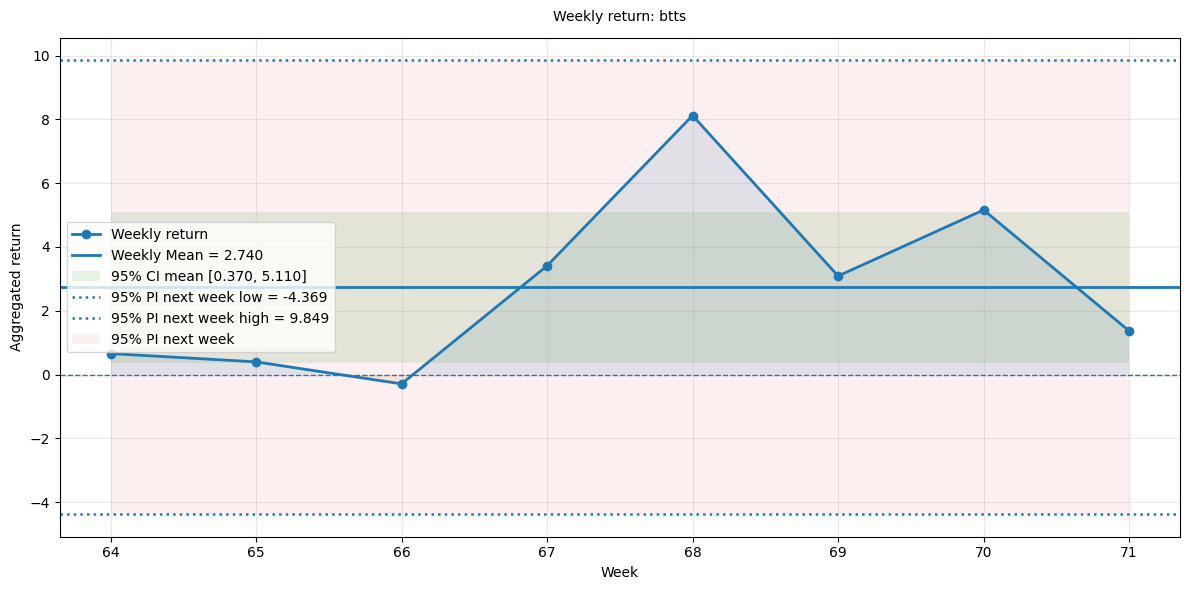

In [6]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"

# Load data
df_loaded = get_btts_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col

###
from datetime import datetime

date_str = "01-08-2026"

date = datetime.strptime(date_str, "%d-%m-%Y")

df = df[df['time'] >= date]
###

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [7]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
btts,2.74,2.83,1.76,6.45,125,0.72


# Over 2.5

In [8]:
target_col = "over_25"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -1.5372781759610161 {'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': False, 'chance1x2_xg_home_min': 1.0, 'chance1x2_xg_home_max': 2.1, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': False, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.1, 'chance1x2_xg_away_max': 1.9000000000000001, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.3000000000000003, 'chance1x2_xg_total_max': 2.8000000000000003}


/tmp/ipykernel_11676/2623453569.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 1.9000000000000001].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/2623453569.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 2.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/2623453569.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 1.8] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 1.7000000000000002].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/2623453569.py:10: UserWarning: The distribution is specified by [2.3000000000000003, 2.9000000000000004] and step=0.1, but the range is 

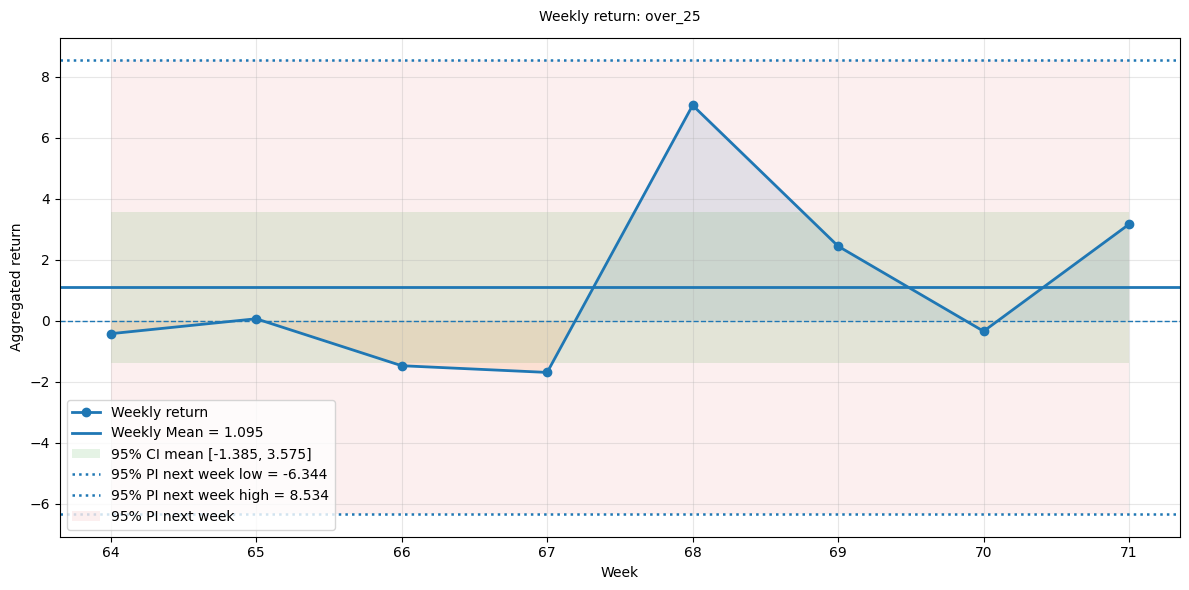

In [9]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "over_25"
odds_col: str = "underOver_quote_currentO"

# Load data
df_loaded = get_over_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col

###
from datetime import datetime

date_str = "01-08-2026"

date = datetime.strptime(date_str, "%d-%m-%Y")

df = df[df['time'] >= date]
###

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [10]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
over_25,1.09,2.97,2.03,7.77,144,0.60


# Under 2.5

In [11]:
target_col = "under_25"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -2.6066027014058095 {'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.0, 'chance1x2_xg_home_max': 1.8000000000000003, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 0.9000000000000001, 'chance1x2_xg_away_max': 1.0, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': False, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.7, 'chance1x2_xg_total_max': 2.8000000000000003}


/tmp/ipykernel_11676/536828116.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 1.9000000000000001].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/536828116.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 2.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/536828116.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 1.8] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 1.7000000000000002].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/536828116.py:10: UserWarning: The distribution is specified by [2.3000000000000003, 2.9000000000000004] and step=0.1, but the range is not 

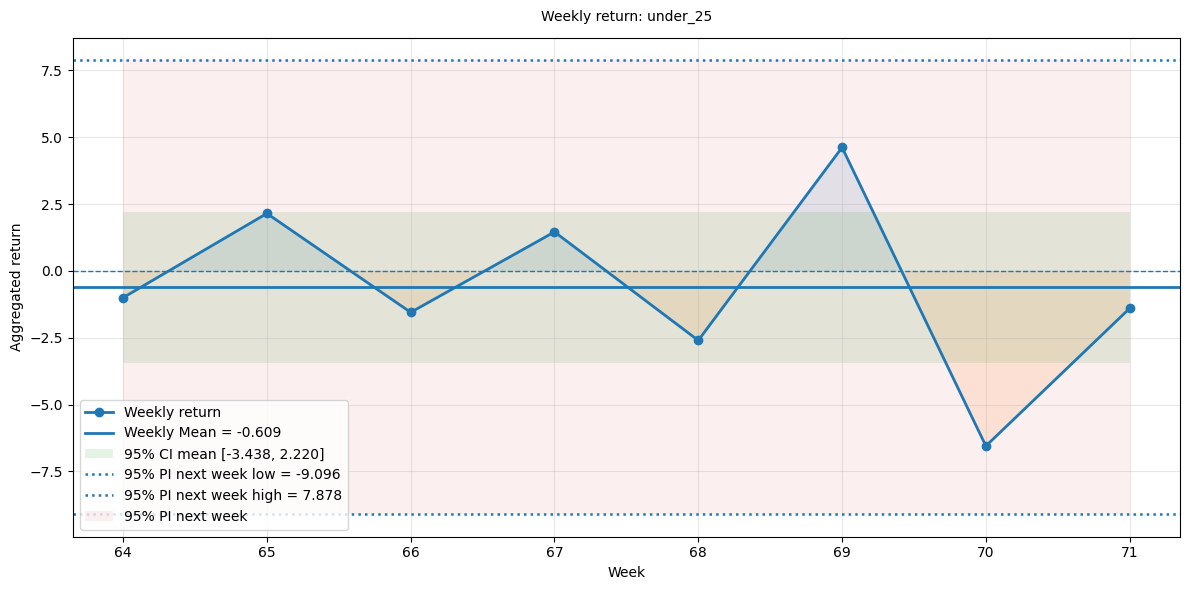

In [12]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "under_25"
odds_col: str = "underOver_quote_currentU"

# Load data
df_loaded = get_under_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col

###
from datetime import datetime

date_str = "01-08-2026"

date = datetime.strptime(date_str, "%d-%m-%Y")

df = df[df['time'] >= date]
###

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [13]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
under_25,-0.61,3.38,1.79,7.10,127,0.46


# Win 1

In [14]:
target_col = "win_1"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -2.1899069843139545 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': False, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.1, 'chance1x2_xg_home_max': 1.8000000000000003, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 1.5, 'chance1x2_xg_away_max': 1.7000000000000002, 'chance1x2_xg_total_use_min': False, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.5000000000000004, 'chance1x2_xg_total_max': 2.7}


/tmp/ipykernel_11676/2995726167.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 1.9000000000000001].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/2995726167.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 2.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/2995726167.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 1.8] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 1.7000000000000002].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/2995726167.py:10: UserWarning: The distribution is specified by [2.3000000000000003, 2.9000000000000004] and step=0.1, but the range is 

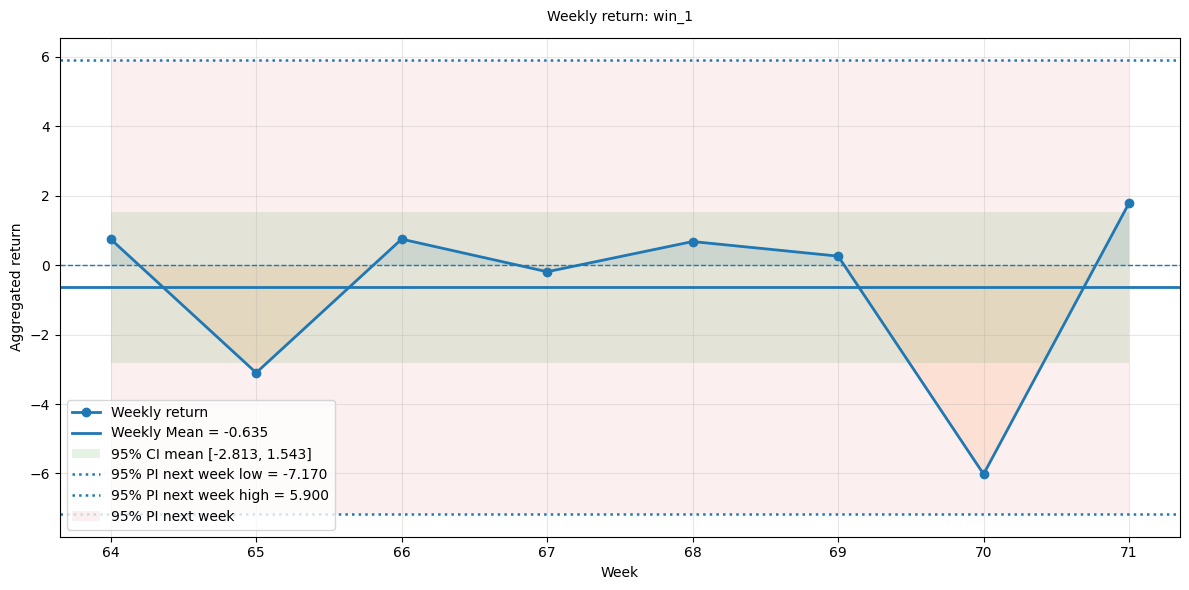

In [15]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "win_1"
odds_col: str = "chance1x2_quote_current1"

# Load data
df_loaded = get_win_1_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col

###
from datetime import datetime

date_str = "01-08-2026"

date = datetime.strptime(date_str, "%d-%m-%Y")

df = df[df['time'] >= date]
###

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [16]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
win_1,-0.63,2.61,1.87,6.92,133,0.59


# Win 2

In [17]:
target_col = "win_2"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -2.7816202972250244 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.2000000000000002, 'chance1x2_xg_home_max': 1.8000000000000003, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.3000000000000003, 'chance1x2_xg_away_max': 1.6, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.3000000000000003, 'chance1x2_xg_total_max': 2.9000000000000004}


/tmp/ipykernel_11676/3755587584.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 1.9000000000000001].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/3755587584.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 2.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/3755587584.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 1.8] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 1.7000000000000002].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/3755587584.py:10: UserWarning: The distribution is specified by [2.3000000000000003, 2.9000000000000004] and step=0.1, but the range is 

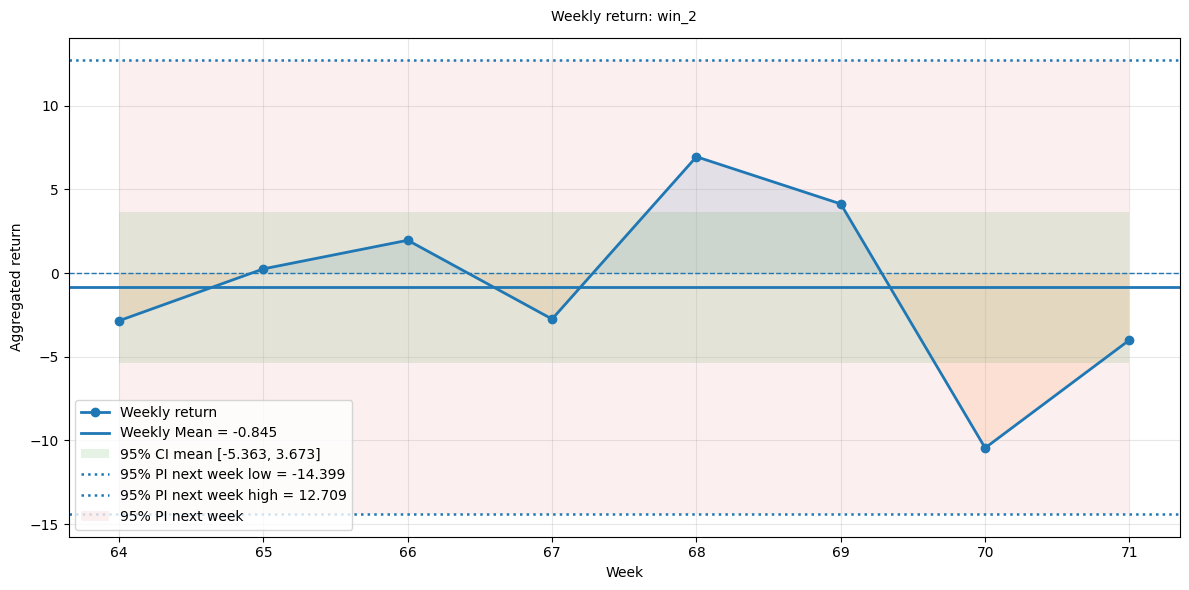

In [18]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "win_2"
odds_col: str = "chance1x2_quote_current2"

# Load data
df_loaded = get_win_2_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col

###
from datetime import datetime

date_str = "01-08-2026"

date = datetime.strptime(date_str, "%d-%m-%Y")

df = df[df['time'] >= date]
###


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [19]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
win_2,-0.85,5.40,2.39,8.73,170,0.24


# NTTS

In [29]:
target_col = "ntts"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -1.514955457053651 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 0.7000000000000001, 'chance1x2_xg_home_max': 1.9000000000000004, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': False, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 1.0, 'chance1x2_xg_away_max': 1.2000000000000002, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': False, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.6000000000000005, 'chance1x2_xg_total_max': 2.7}


/tmp/ipykernel_11676/622371349.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 1.9000000000000001].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/622371349.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 2.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/622371349.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 1.8] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 1.7000000000000002].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/622371349.py:10: UserWarning: The distribution is specified by [2.3000000000000003, 2.9000000000000004] and step=0.1, but the range is not 

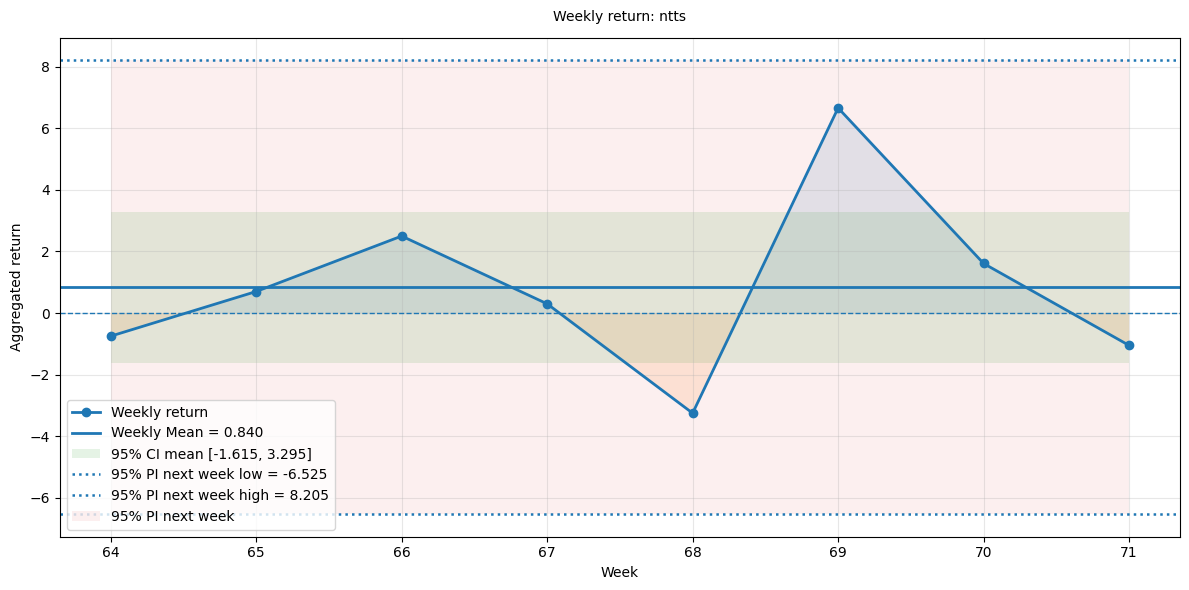

In [31]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "ntts"
odds_col: str = "goalNoGoal_quote_currentNG"

# Load data
df_loaded = get_ntts_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col

###
from datetime import datetime

date_str = "01-08-2026"

date = datetime.strptime(date_str, "%d-%m-%Y")

df = df[df['time'] >= date]
###


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [32]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
ntts,0.84,2.94,1.82,7.19,129,0.48


# Tie

In [20]:
target_col = "tie"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 2.039268493015353 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 0.7000000000000001, 'chance1x2_xg_home_max': 1.6, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.2000000000000002, 'chance1x2_xg_away_max': 1.6, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': False, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.4000000000000004, 'chance1x2_xg_total_max': 2.5000000000000004}


/tmp/ipykernel_11676/3079384204.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 1.9000000000000001].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/3079384204.py:10: UserWarning: The distribution is specified by [0.7000000000000001, 2.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.7000000000000001, 2.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/3079384204.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 1.8] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 1.7000000000000002].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_11676/3079384204.py:10: UserWarning: The distribution is specified by [2.3000000000000003, 2.9000000000000004] and step=0.1, but the range is 

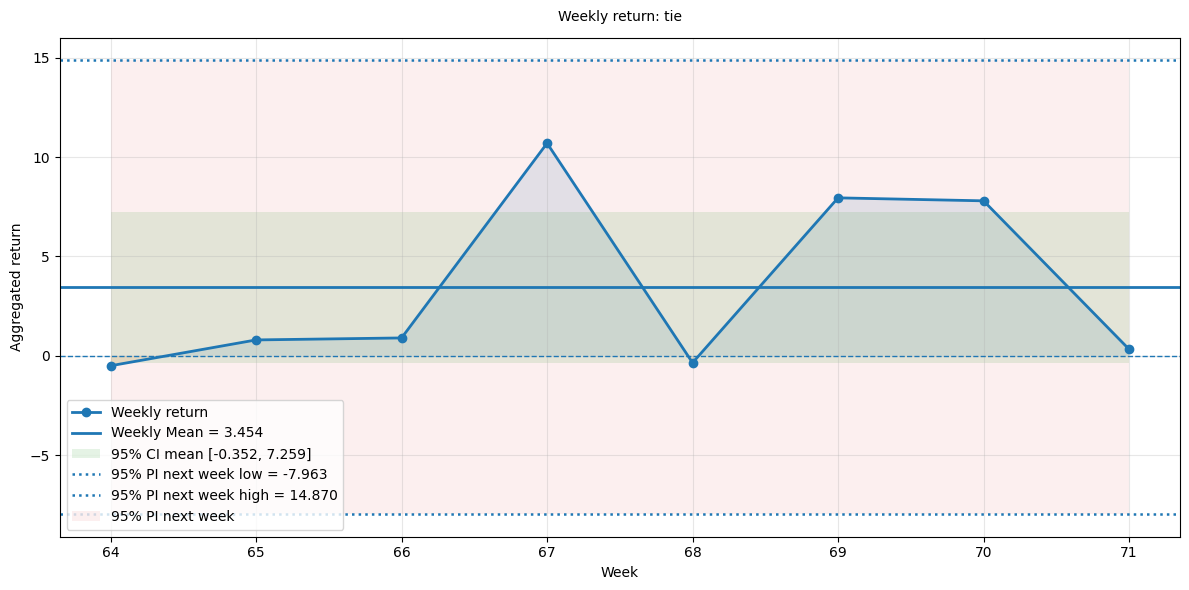

In [21]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "tie"
odds_col: str = "chance1x2_quote_currentx"

# Load data
df_loaded = get_x_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col

###
from datetime import datetime

date_str = "01-08-2026"

date = datetime.strptime(date_str, "%d-%m-%Y")

df = df[df['time'] >= date]
###


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [22]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
tie,3.45,4.55,2.35,8.65,167,0.31


# Forecast

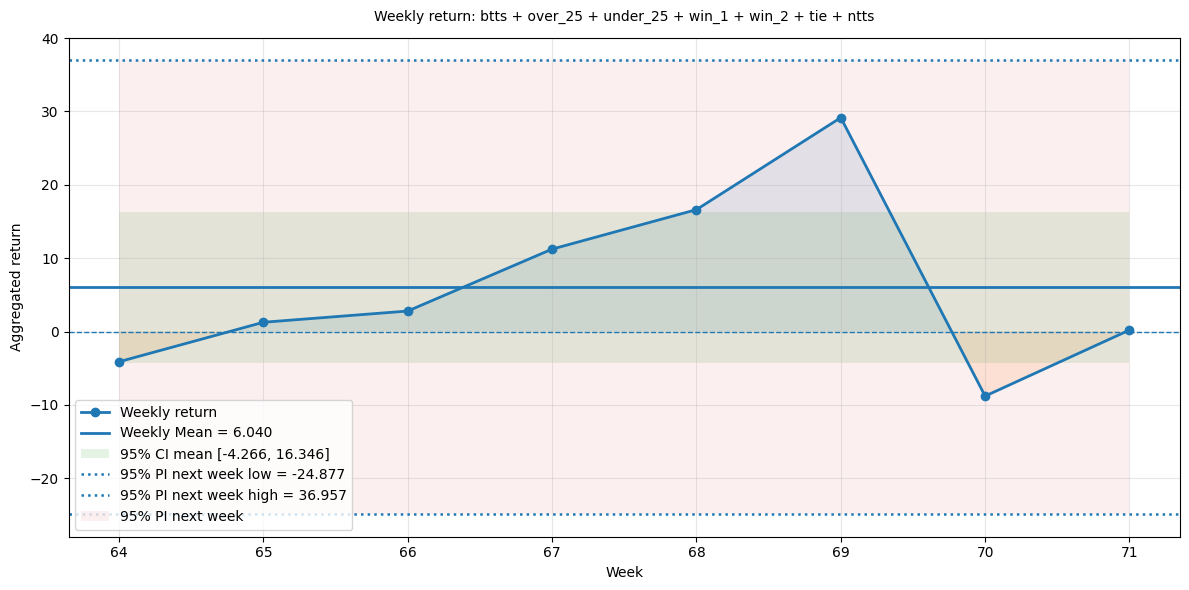

In [33]:
strategies = ['btts', 'over_25', 'under_25', 'win_1', 'win_2', 'tie', 'ntts'] # strategy_dict.keys()

for i, key in enumerate(strategy_dict.keys()):
    if i == 0:
        df_final = strategy_dict[key]['df_filtered']
    else:
        df_item = strategy_dict[key]['df_filtered']
        df_final = pd.concat([df_final, df_item], axis=0)

df_final = df_final.reset_index(drop=True)

weekly_return, stats = analyze_strategies(df_final, strategies=strategies, print_pi=True)

In [34]:
df_final = df_final.rename(columns={"team_league": "league"})

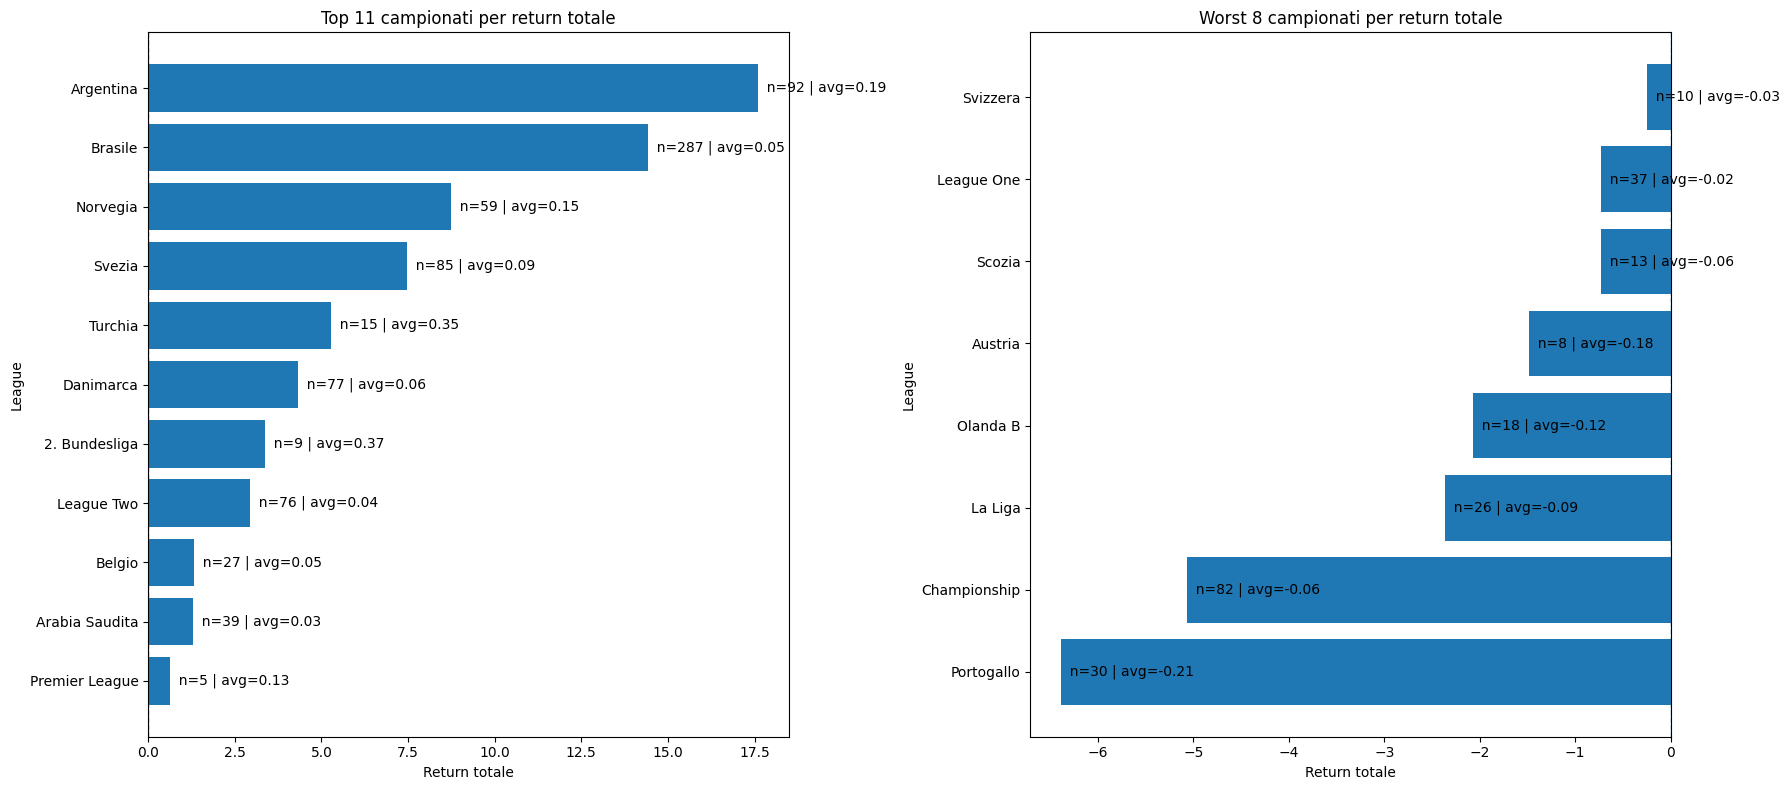

In [35]:
top_leagues = get_best_leagues(df_final, strategies=strategy_dict.keys())

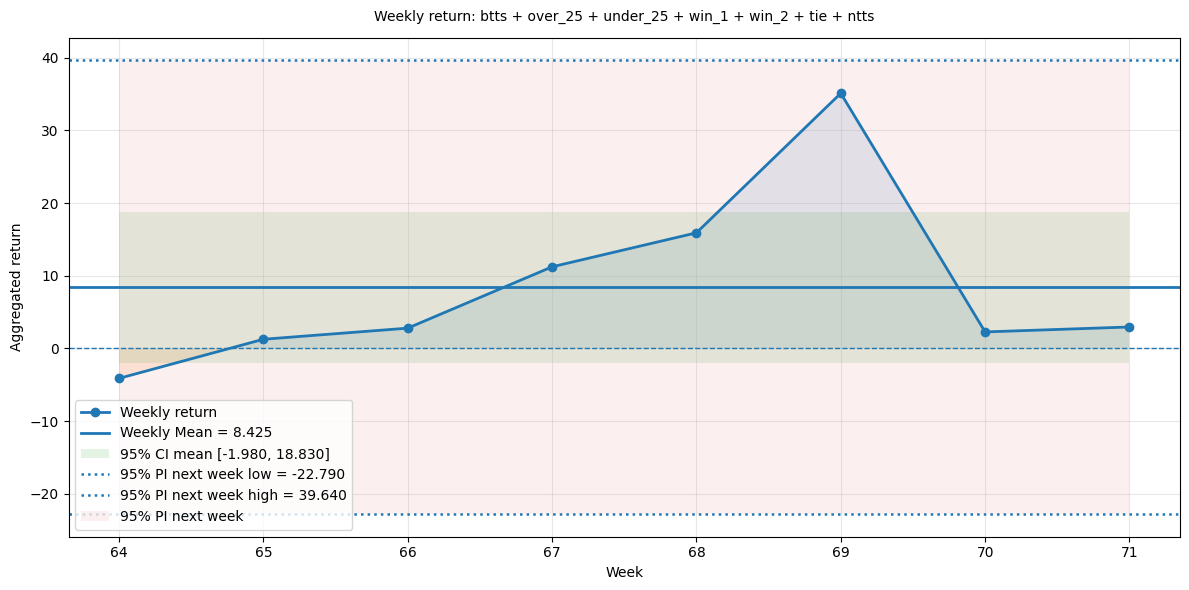

In [36]:
weekly_return, stats = analyze_strategies(df_final, strategies=strategies, leagues=top_leagues.index.to_list(),print_pi=True)

In [27]:
output_dict = dict()

for strategy in strategies:
    output_dict[strategy]= strategy_dict[strategy]['settings']
 
output_dict["top_leagues"] = top_leagues.index.to_list()

In [28]:
import json 
with open("strategies.json", "w", encoding="utf-8") as f:
    json.dump(output_dict, f, indent=2)